<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Perfume_and_Psychology_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perfume and Psychology Dataset

# About the dataset

Our dataset, df_combined, was created by merging three CSV files: perfume_Brainfunc.csv, perfume_Psycho.csv, and perfume_compound.csv. This combined dataset aims to explore the relationships between odorant materials, their effects on brain function (EEG wave changes), psychophysiological responses, and the botanical origins and major chemical components of these materials.

The combined DataFrame consists of 103 entries and 9 columns. The columns include 'S. No.', 'Odorant Materials', 'EEG Wave Changes', 'Brain Functions', 'Reference', 'Psychophysiological Changes', 'Plants Name', 'Botanical Name', and 'Major Components'. Most columns are of 'object' (string) type, with 'S. No.' being the only numerical column.

A significant observation during the initial exploration is the presence of numerous missing values, particularly in 'EEG Wave Changes', 'Brain Functions', 'Psychophysiological Changes', 'Plants Name', 'Botanical Name', and 'Major Components'. This suggests that not all entries have complete information across all categories, likely due to the nature of the original separate datasets.

From the univariate analysis, 'S. No.' behaves as an index with a relatively even distribution. For categorical columns, we see a wide variety of 'Odorant Materials', with 'Lavender oil' appearing most frequently. 'EEG Wave Changes' and 'Brain Functions' also show diverse descriptions, indicating a broad range of studied effects. The 'Plants Name', 'Botanical Name', and 'Major Components' columns, originating from df_compound, are only populated for a small subset of the total entries, highlighting that detailed chemical breakdown is not available for all odorant materials.

The bivariate analysis (specifically box plots of numerical 'S. No.' against categorical features) further emphasized the data sparsity, as many plots were skipped due to insufficient non-null data for various categorical-numerical combinations. This initial overview suggests that a significant part of the analysis will involve handling missing data and focusing on the well-populated columns first.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

### Word Cloud for Textual Columns

For columns with descriptive text like 'Brain Functions' or 'Psychophysiological Changes', a word cloud can quickly highlight the most frequent words and therefore the main themes. This requires some text preprocessing steps like lowercasing, removing stop words, and tokenization. Below is an example of how you might generate a word cloud for the 'Brain Functions' column. (Note: You may need to install the `wordcloud` library if you haven't already: `!pip install wordcloud`)


In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d priyanshubhaskar/perfume-and-psychology

# Unziping the downloaded file
!unzip perfume-and-psychology.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/priyanshubhaskar/perfume-and-psychology
License(s): CC0-1.0
  0% 0.00/7.00k [00:00<?, ?B/s]
100% 7.00k/7.00k [00:00<00:00, 32.3MB/s]
Archive:  perfume-and-psychology.zip
  inflating: perfume_Brainfunc.csv   
  inflating: perfume_Psycho.csv      
  inflating: perfume_compound.csv    


In [3]:
df_brainfunc = pd.read_csv('/content/perfume_Brainfunc.csv')
df_psycho = pd.read_csv('/content/perfume_Psycho.csv')
df_compound = pd.read_csv('/content/perfume_compound.csv')

In [5]:
df_combined = pd.concat([df_brainfunc, df_psycho, df_compound], ignore_index=True)

print("Combined DataFrame Head:")
display(df_combined.head())

Combined DataFrame Head:


,S. No.,Odorant Materials,EEG Wave Changes,Brain Functions,Reference,Psychophysiological Changes,Plants Name,Botanical Name,Major Components
0,1.0,Galaxolide,Alpha decreased.,Odors produce divided attention even when unde...,[74],NaN,NaN,NaN,NaN
1,2.0,m-Xylene,Alpha increased.,Stimulating and excitatory effects.,[75],NaN,NaN,NaN,NaN
2,3.0,"Birch tar, galbanum, heliotropine, jasmine, la...","Increased theta for birch tar, jasmine, lavend...",Subjects differed in their subjective response...,[80],NaN,NaN,NaN,NaN
3,4.0,"5-α-Androstan-3-one, bangalol, white sapphire,...",Alpha increased.,From more anterior electrodes—related to psych...,[70],NaN,NaN,NaN,NaN
4,5.0,Phenylethyl alcohol and valeric acid,Valeric acid—alpha 2 increased.,Unpleasant odor leads to a cortical deactivation.,[76],NaN,NaN,NaN,NaN


In [6]:
df_combined.shape

(103, 9)

In [7]:
df_combined.columns

Index(['S. No.', 'Odorant Materials', 'EEG Wave Changes', 'Brain Functions',
       'Reference', 'Psychophysiological Changes', 'Plants Name',
       'Botanical Name', 'Major Components'],
      dtype='object')

In [8]:
df_combined.dtypes

,0
S. No.,float64
Odorant Materials,object
EEG Wave Changes,object
Brain Functions,object
Reference,object
Psychophysiological Changes,object
Plants Name,object
Botanical Name,object
Major Components,object


In [9]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   S. No.                       80 non-null     float64
 1   Odorant Materials            80 non-null     object 
 2   EEG Wave Changes             42 non-null     object 
 3   Brain Functions              42 non-null     object 
 4   Reference                    80 non-null     object 
 5   Psychophysiological Changes  38 non-null     object 
 6   Plants Name                  23 non-null     object 
 7   Botanical Name               23 non-null     object 
 8   Major Components             23 non-null     object 
dtypes: float64(1), object(8)
memory usage: 7.4+ KB


In [10]:
df_combined.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
S. No.,80.0,NaN,NaN,NaN,20.55,11.702969,1.0,10.75,20.5,30.25,42.0
Odorant Materials,80,72,Lavender oil,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EEG Wave Changes,42,41,Alpha increased.,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brain Functions,42,42,Odors produce divided attention even when unde...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Reference,80,79,[141],2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Psychophysiological Changes,38,38,Geranium oil inhalation—both state and trait s...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Plants Name,23,23,Bergamot,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Botanical Name,23,23,Citrus bergamia,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Major Components,23,23,"limonene, linalool, linalyl acetate",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df_combined.isnull().sum()

,0
S. No.,23
Odorant Materials,23
EEG Wave Changes,61
Brain Functions,61
Reference,23
Psychophysiological Changes,65
Plants Name,80
Botanical Name,80
Major Components,80


### Missing Values Heatmap

Visualizing the patterns of missing values can reveal important information about the data collection process and potential biases. A heatmap of `df_combined.isnull()` can quickly show where the data is sparse across different columns.

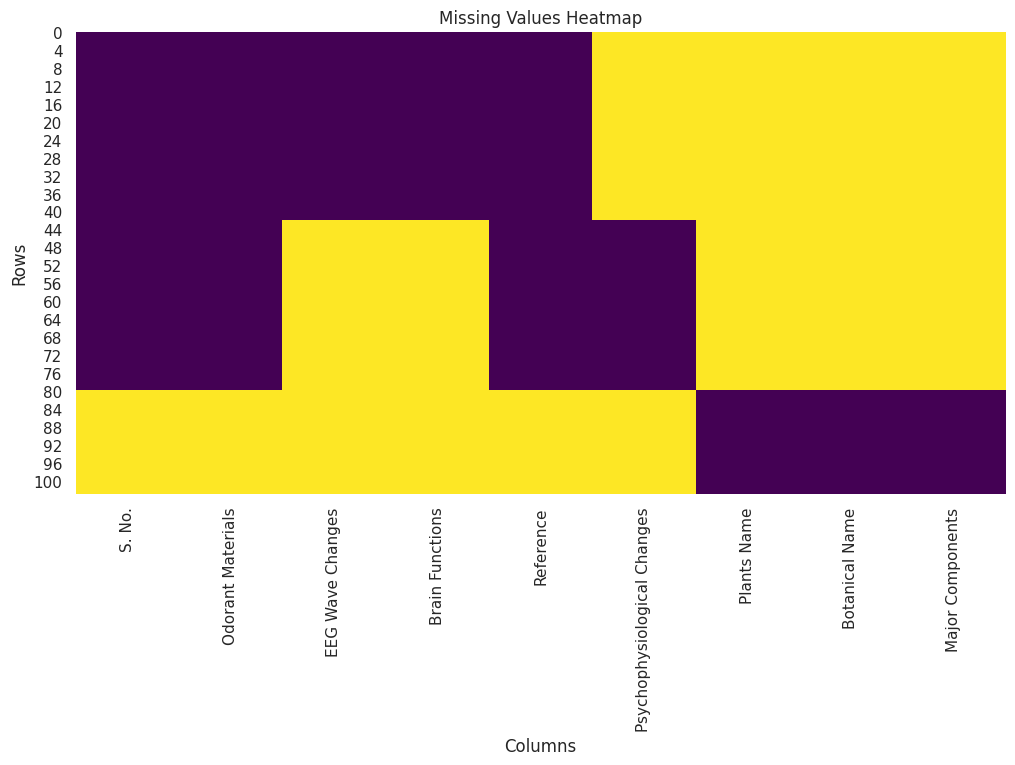

In [24]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_combined.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

In [12]:
df_combined.duplicated().sum()

np.int64(0)

# Univariate Analysis

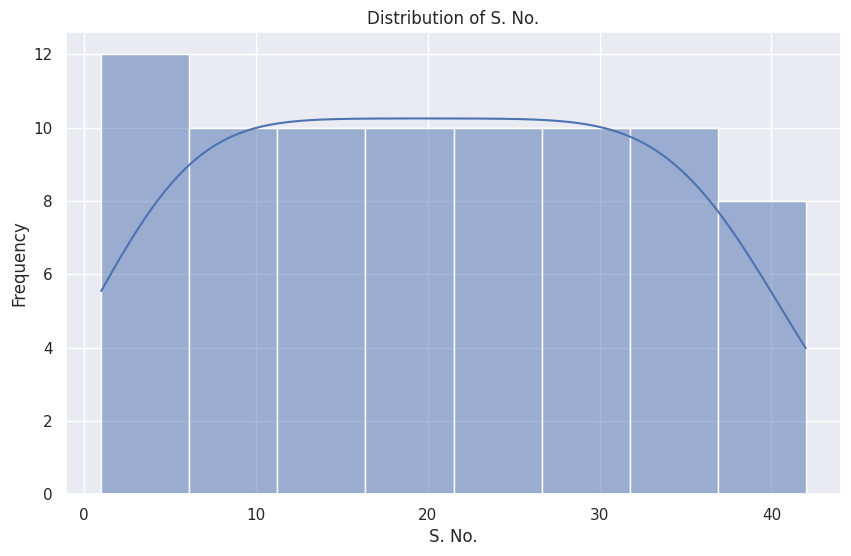

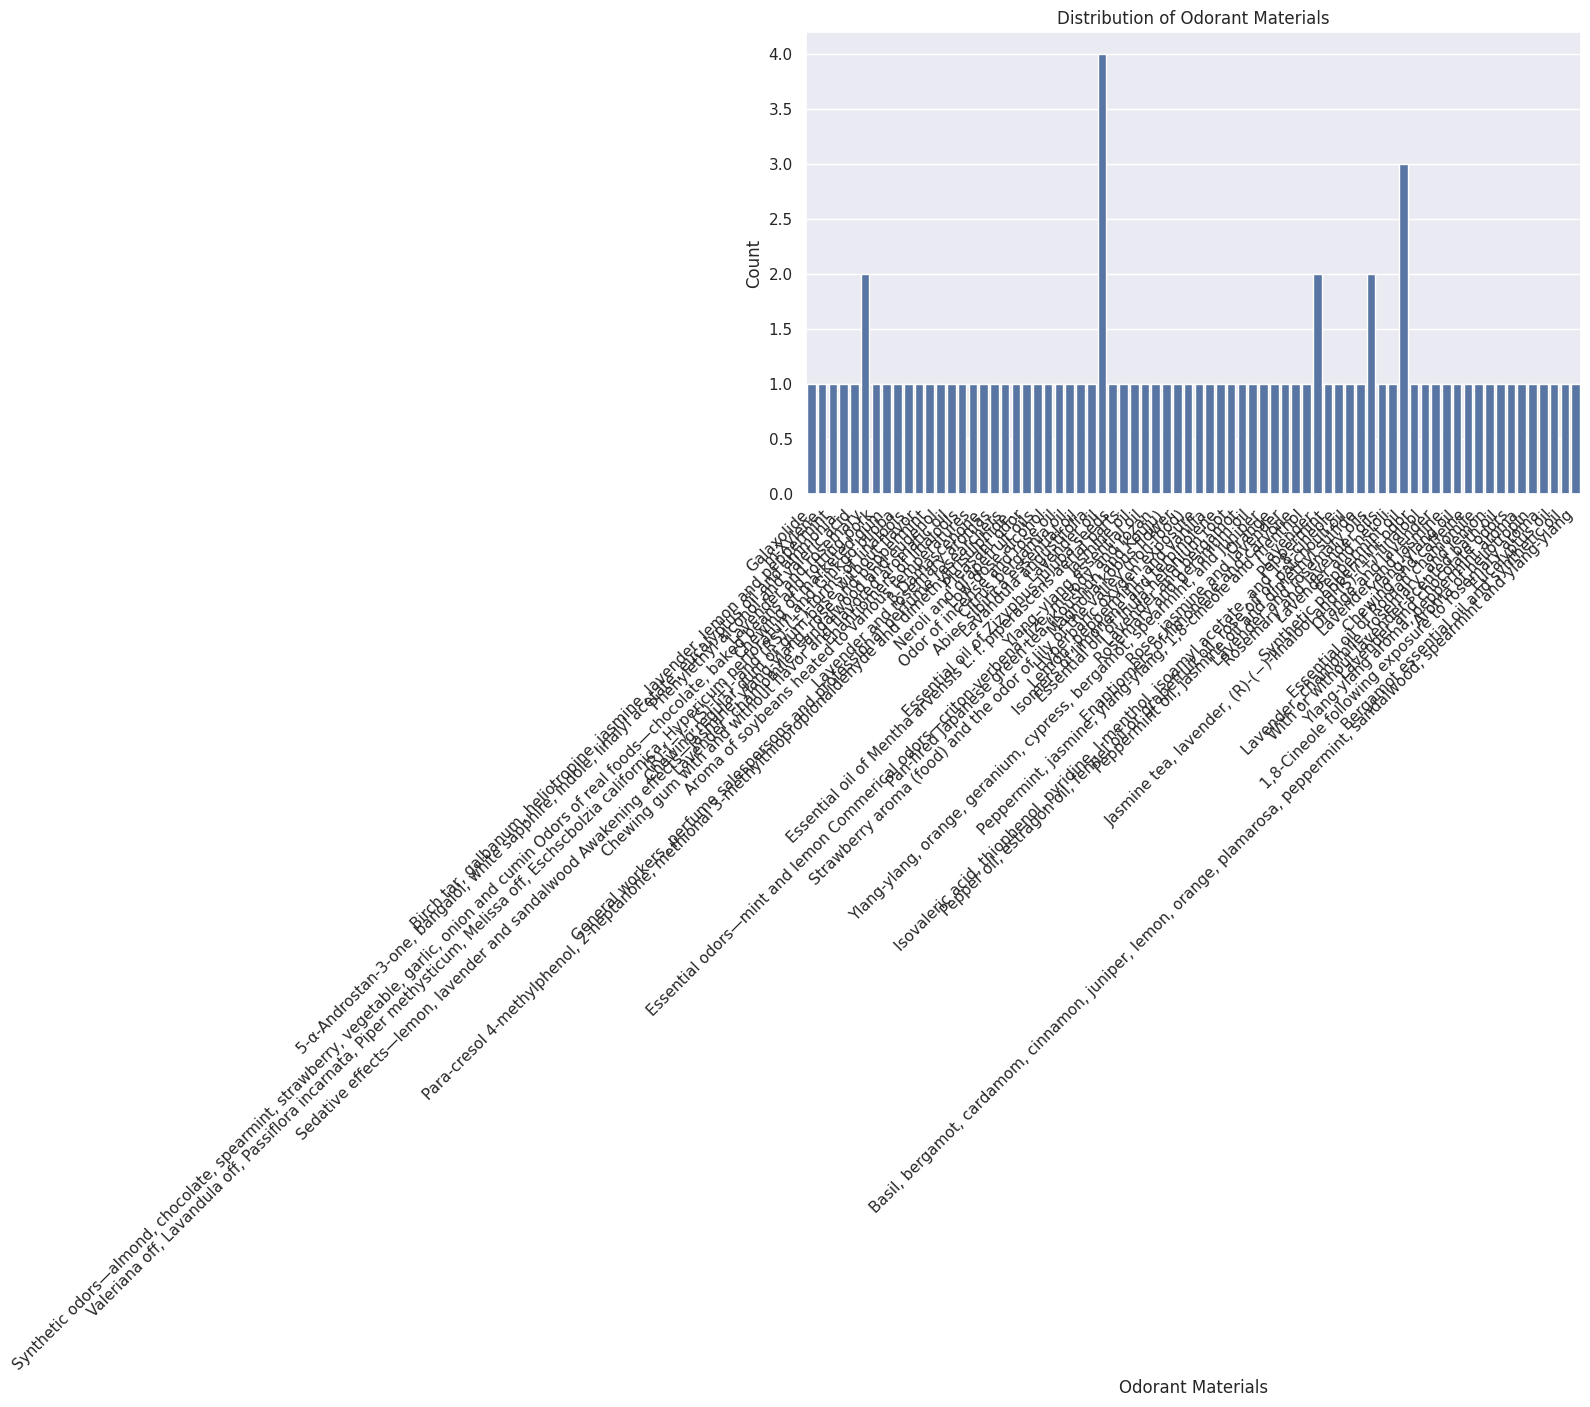

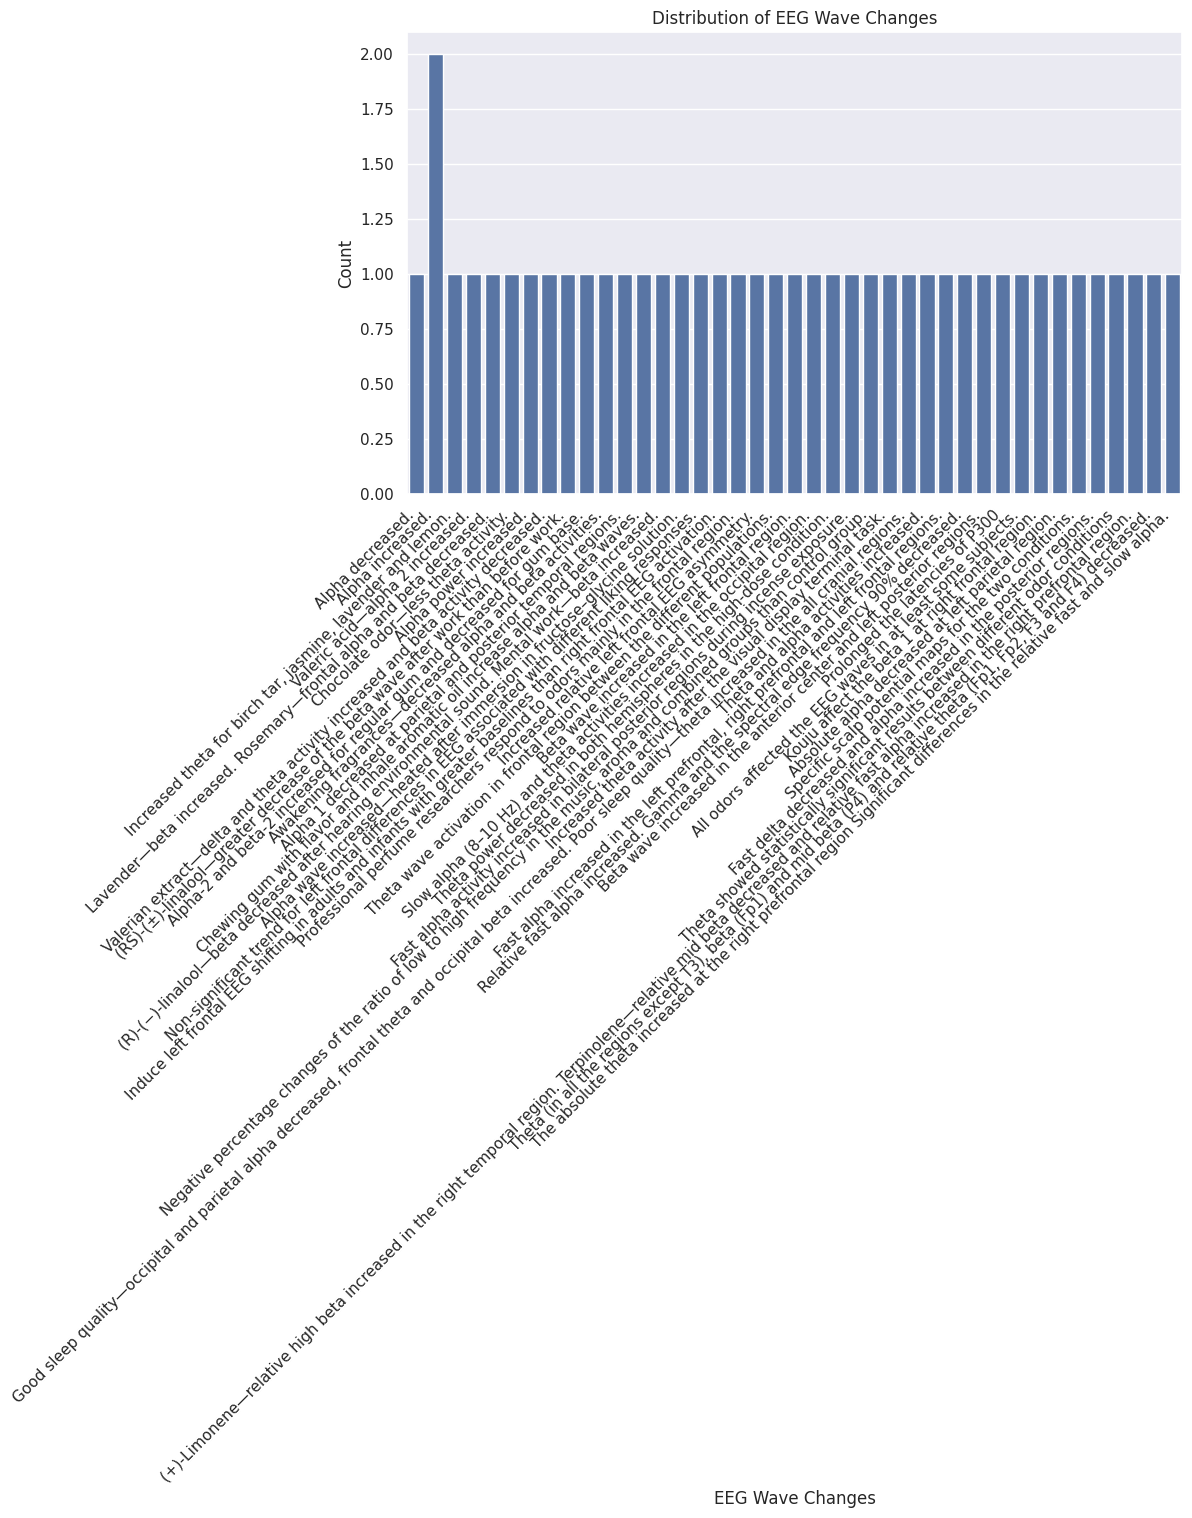

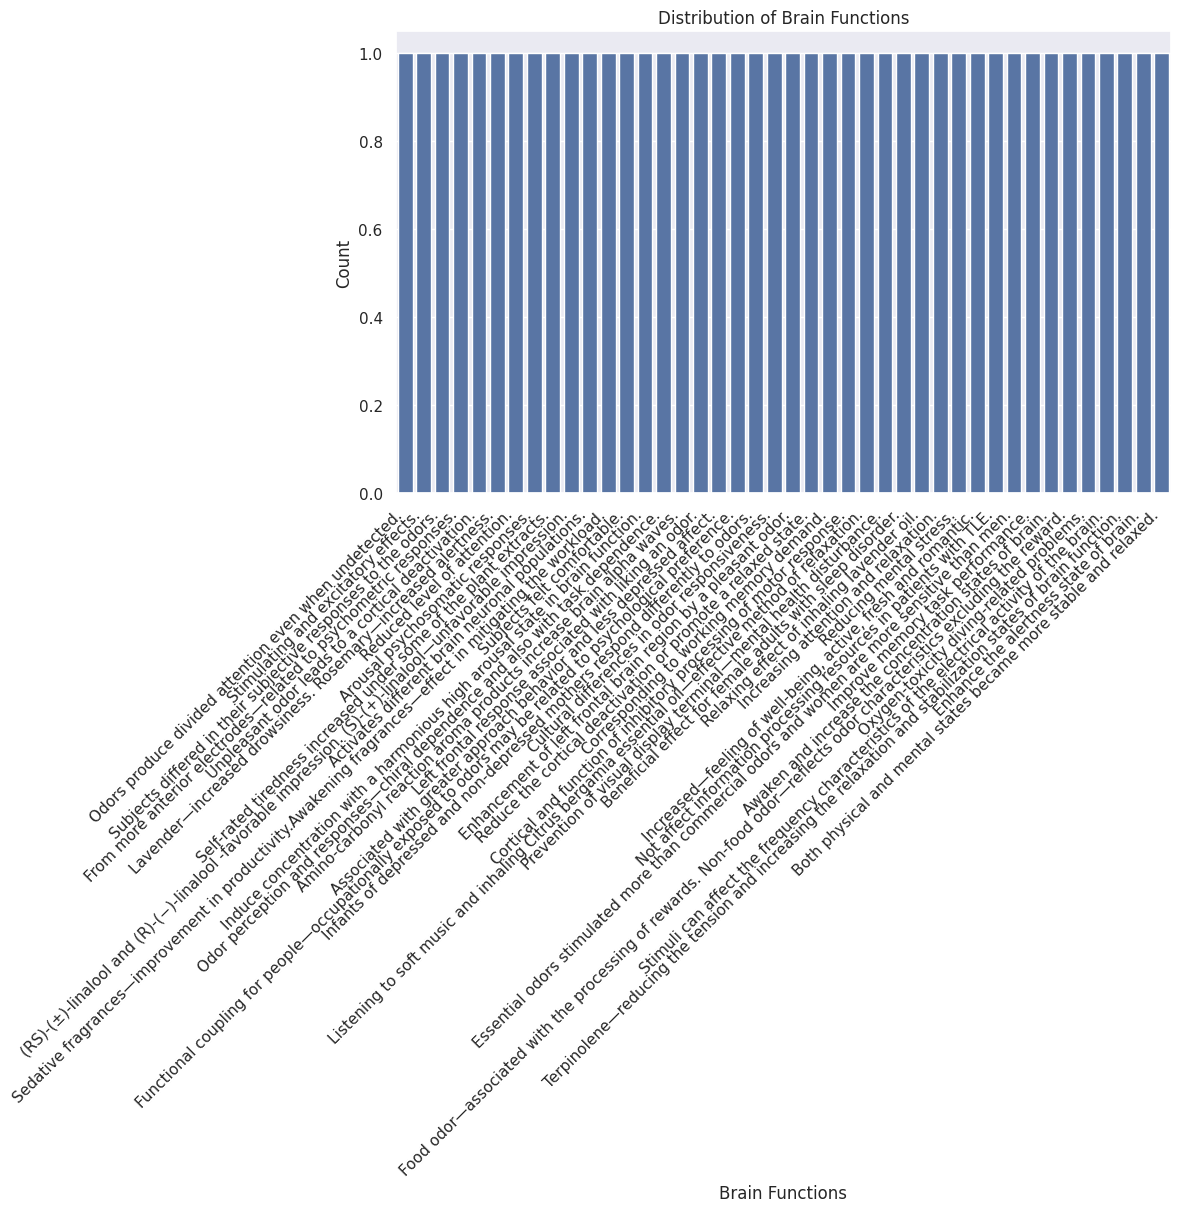

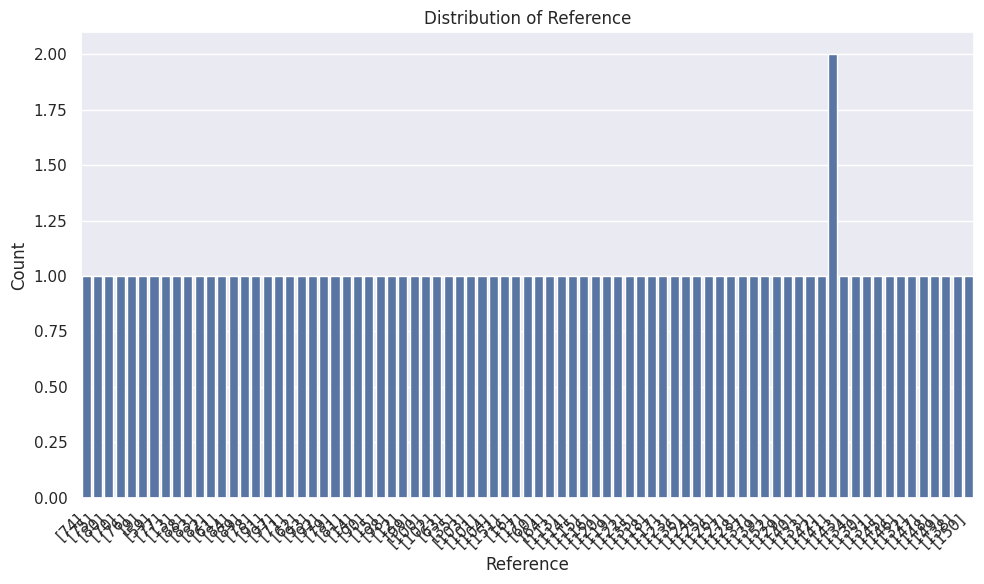

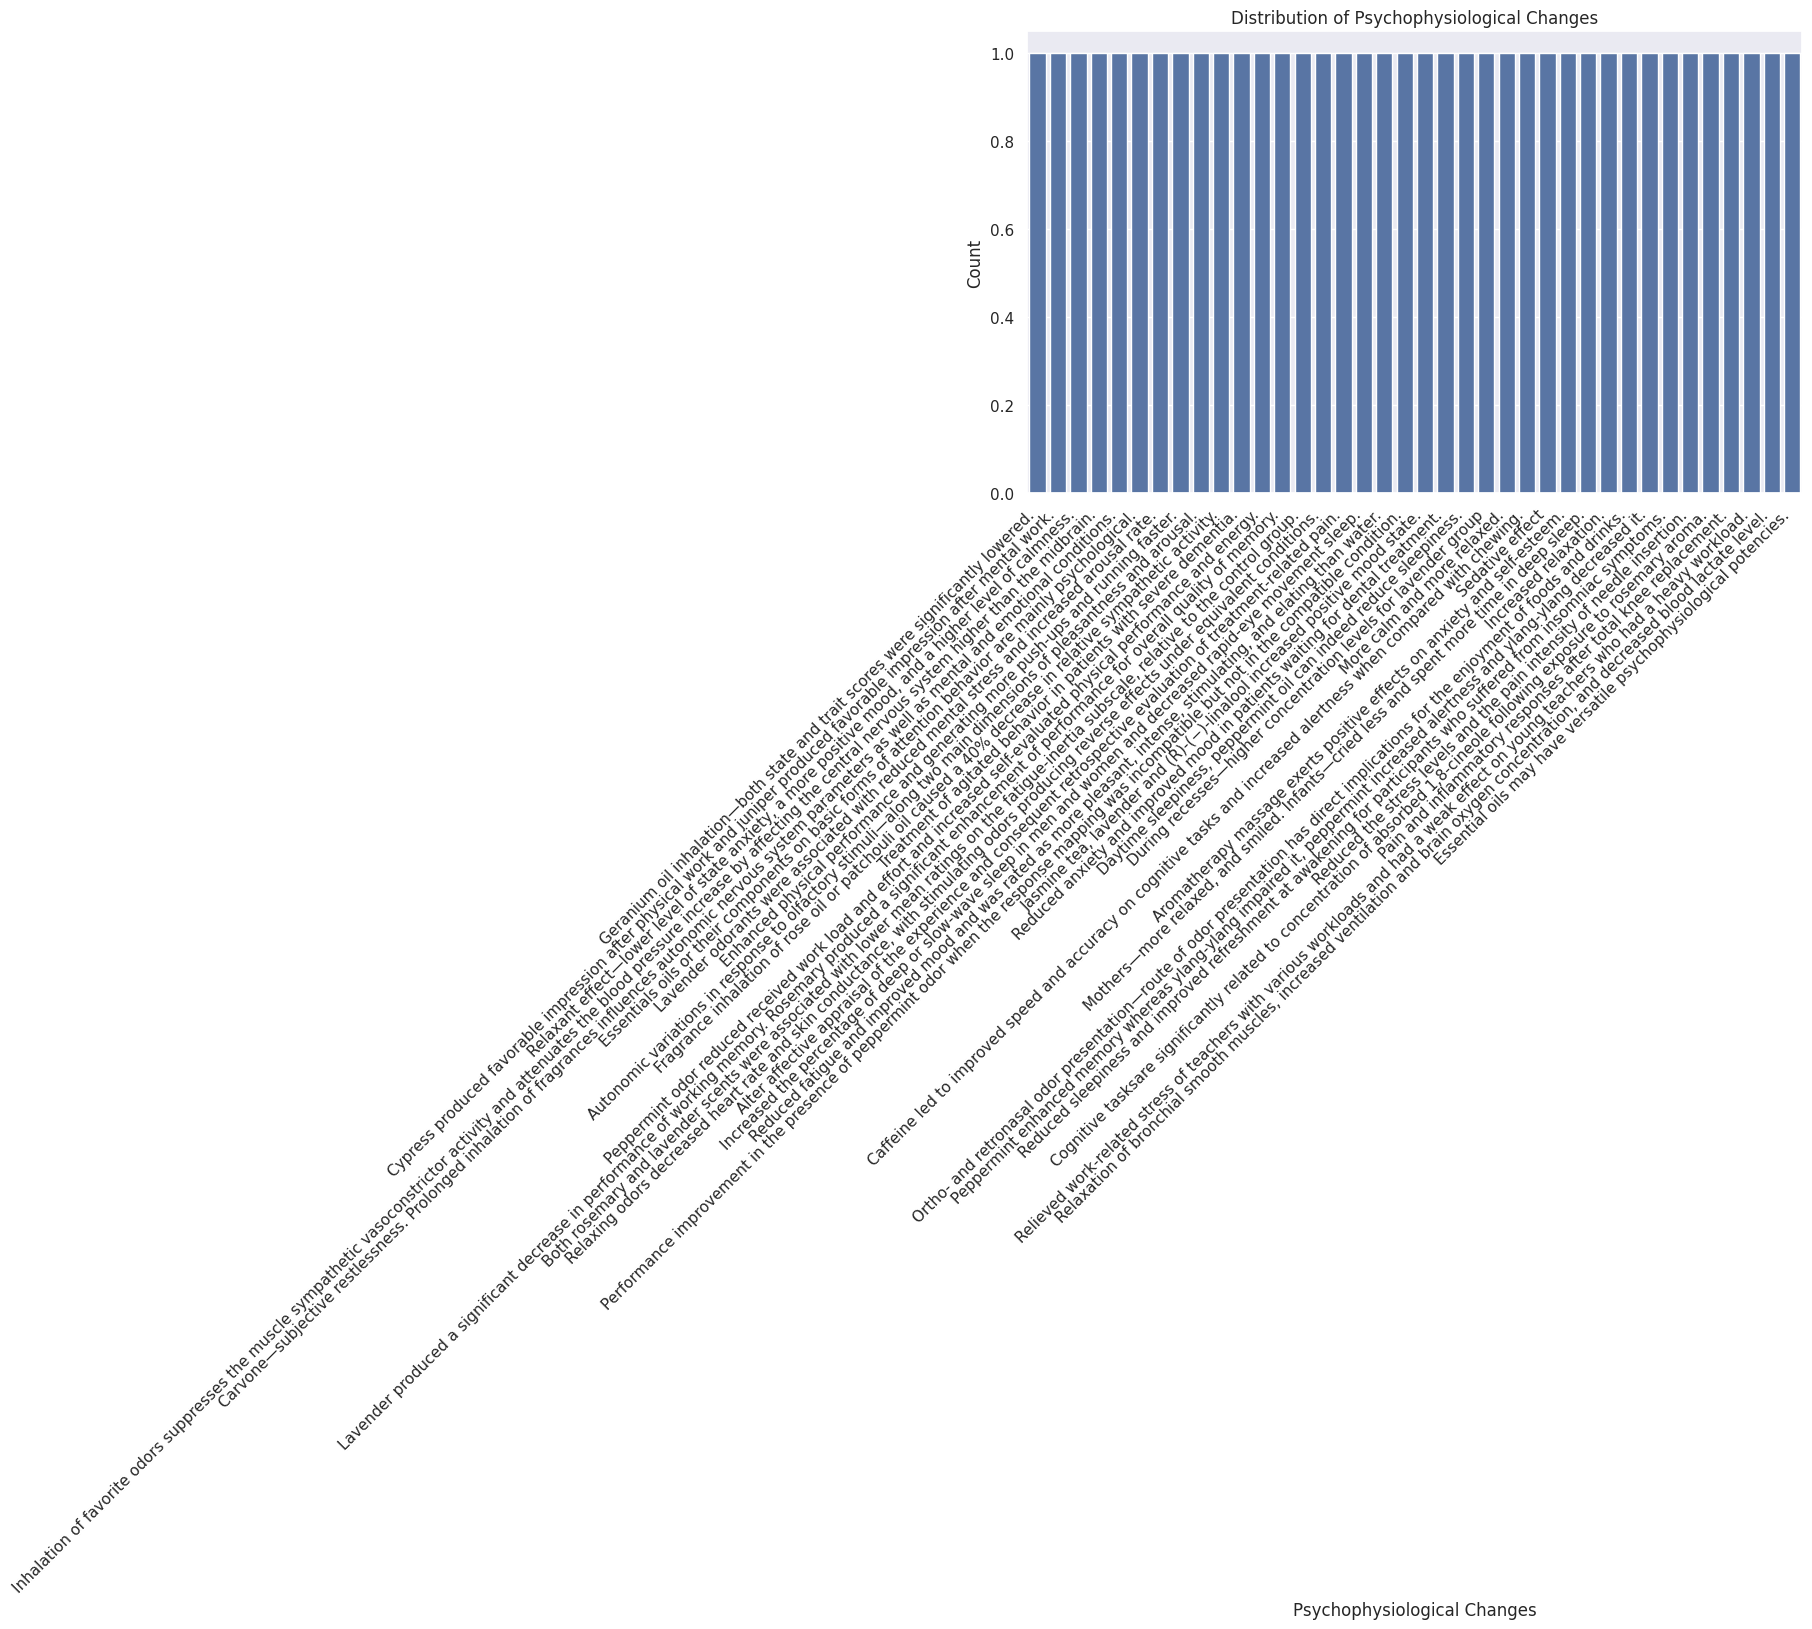

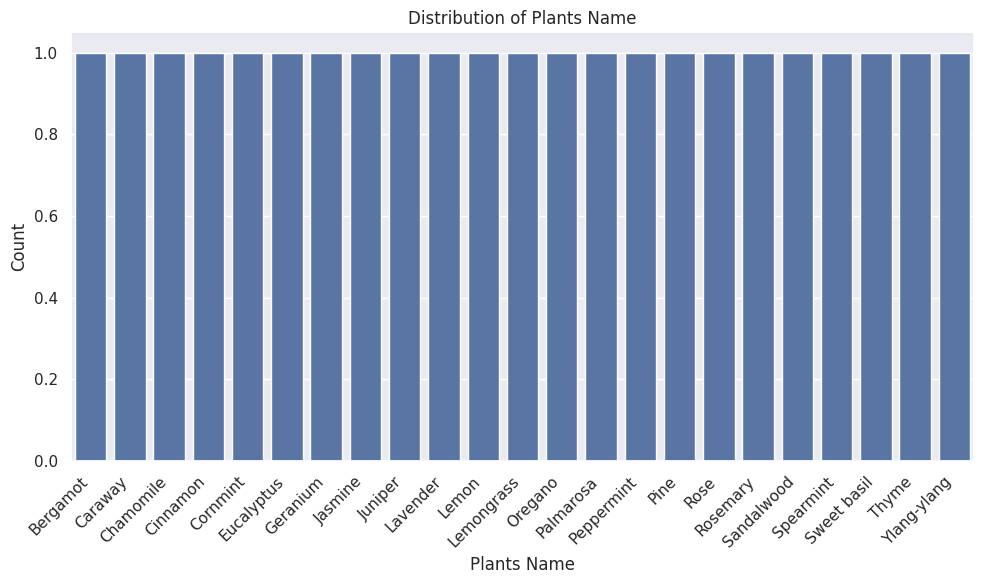

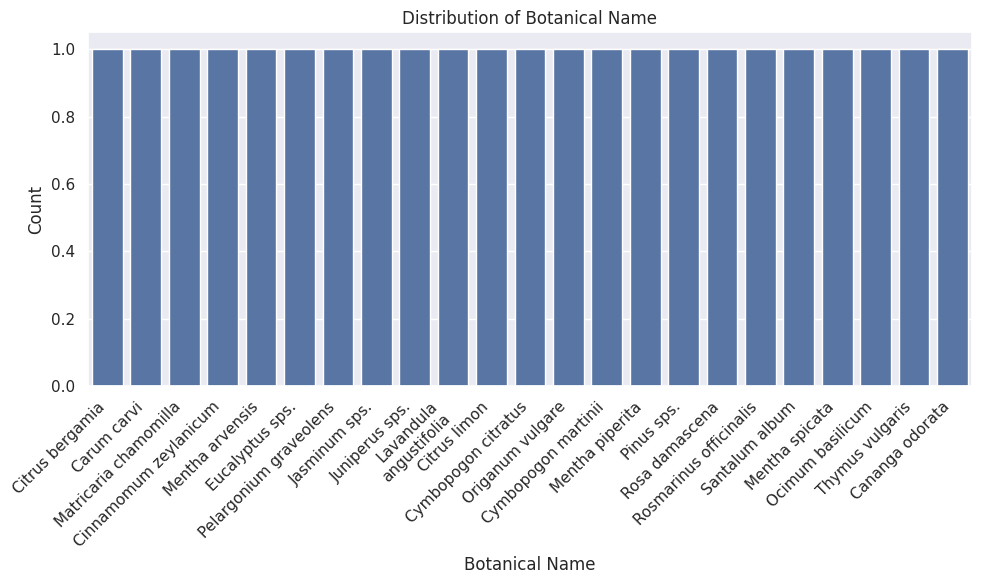

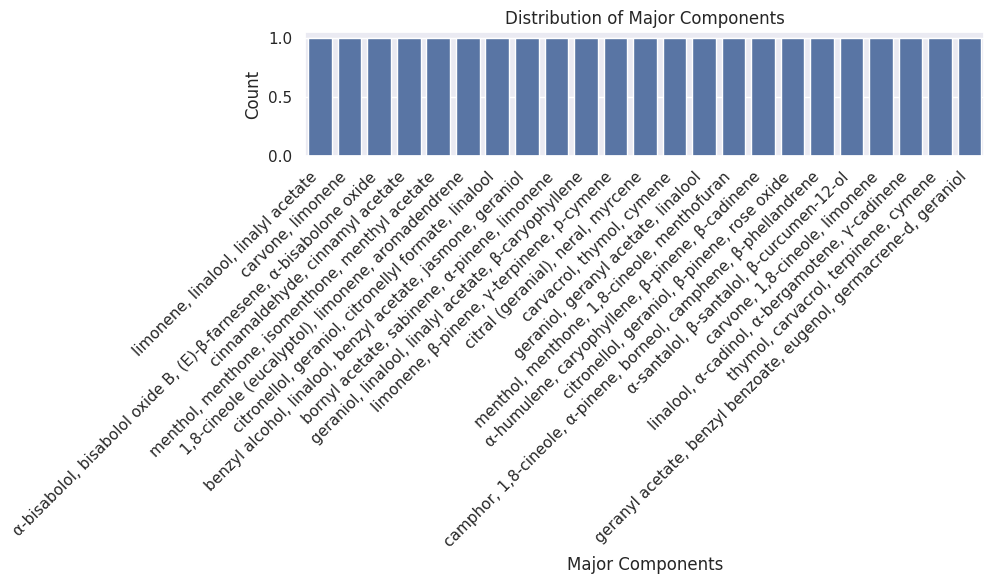

Value counts for Odorant Materials:
Odorant Materials
Lavender oil                                                                                                                 4
Peppermint oil                                                                                                               3
Lavender and rosemary                                                                                                        2
Lavender                                                                                                                     2
Lavender and rosemary oils                                                                                                   2
                                                                                                                            ..
Aroma of heliotropin                                                                                                         1
1,8-Cineole following exposure to rosemary aroma         

In [14]:
# Getting a list of numerical columns
numerical_cols = df_combined.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_combined, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df_combined.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_combined, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df_combined[col].value_counts()}\n")

# Bivariate Analysis

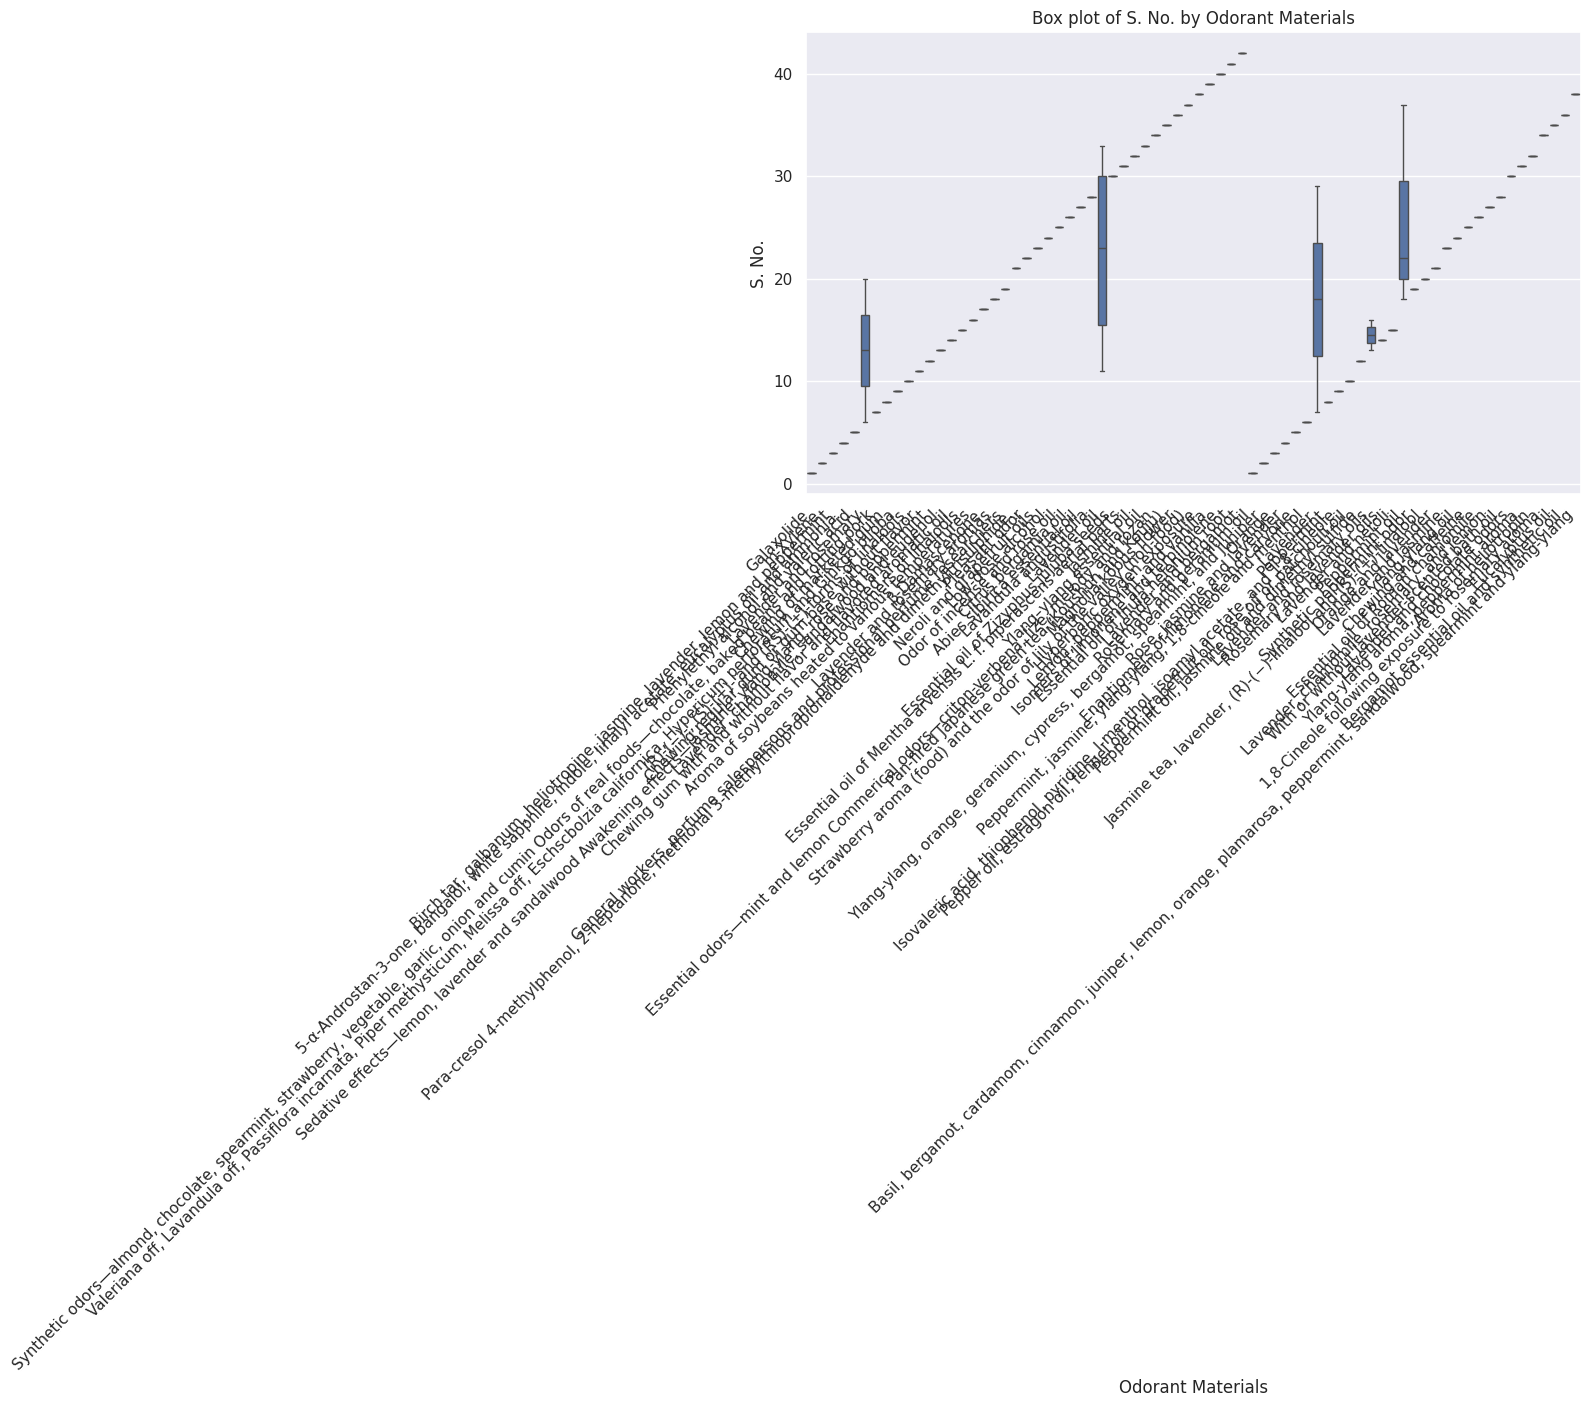

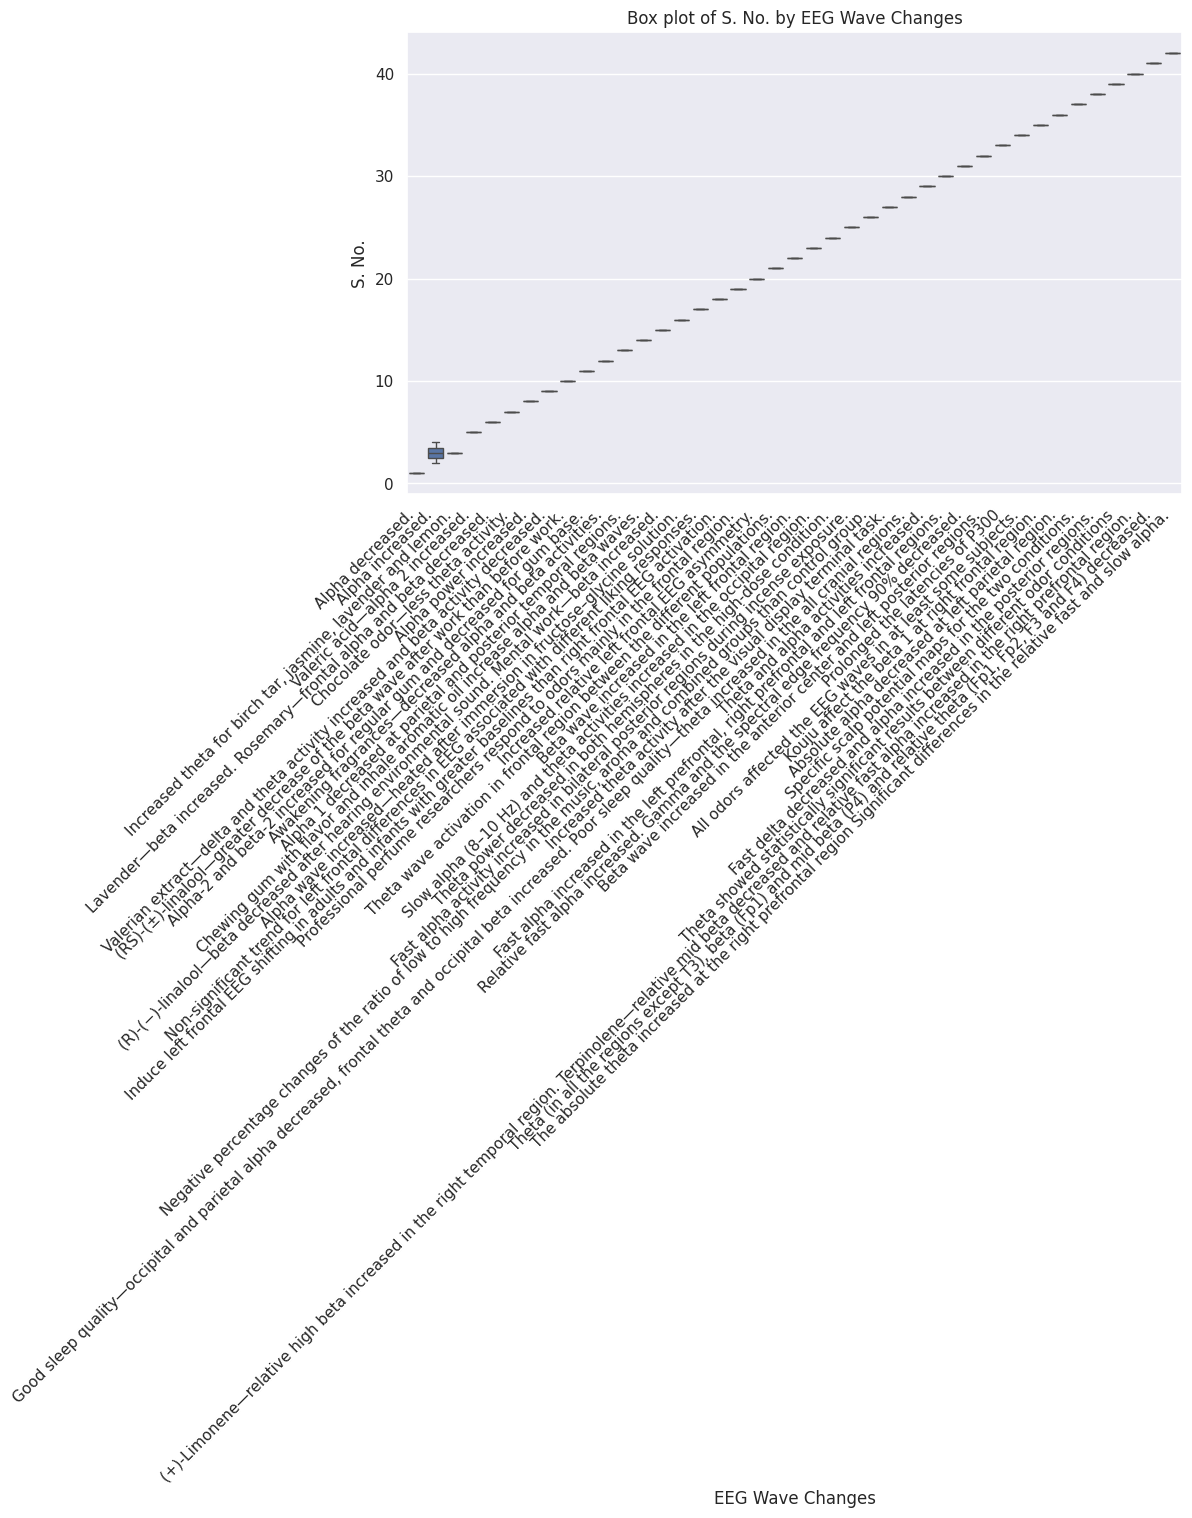

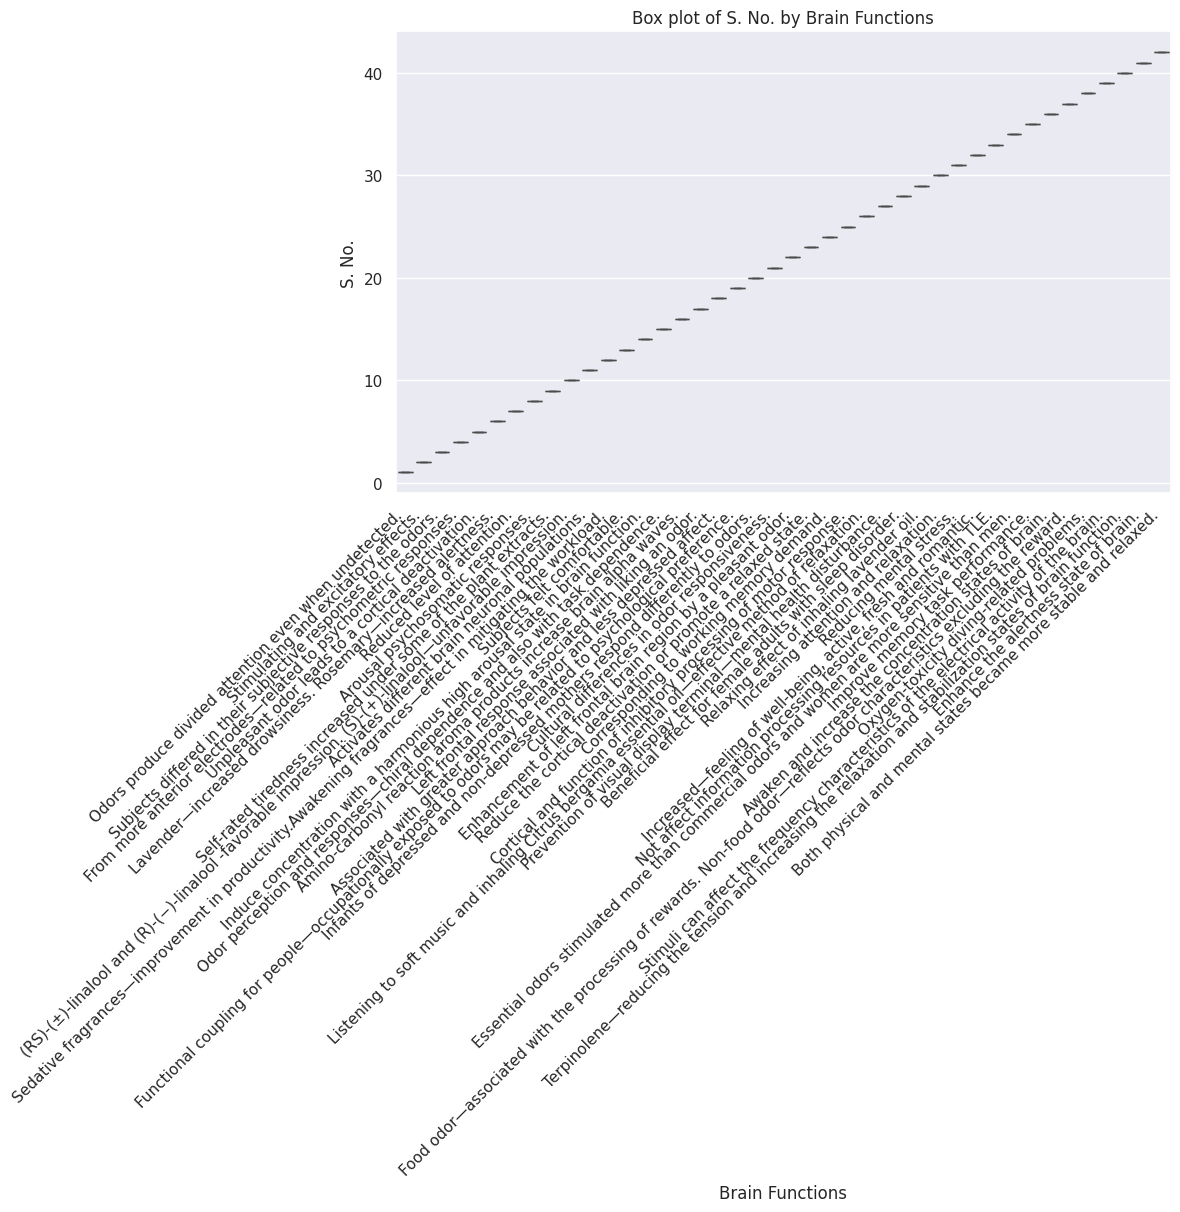

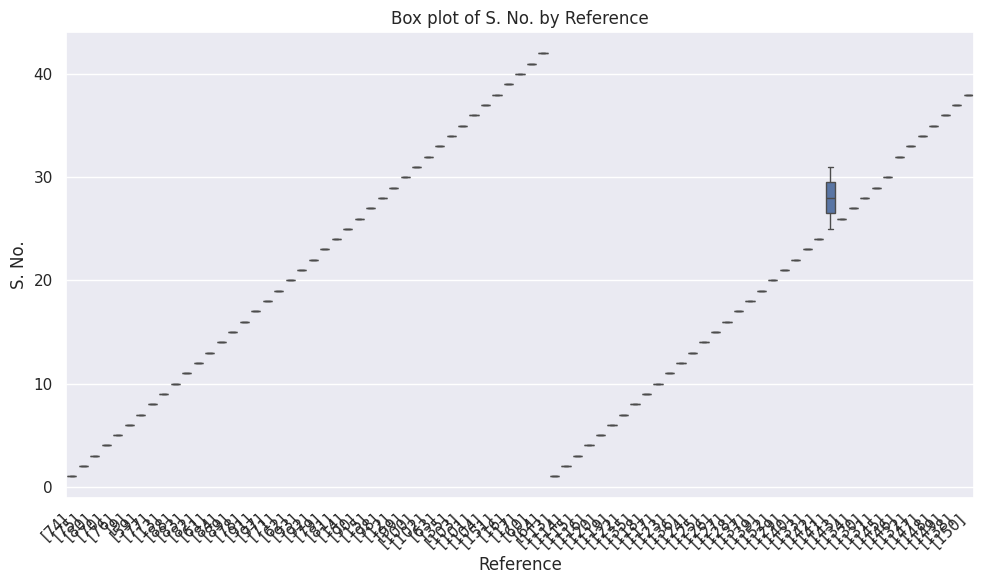

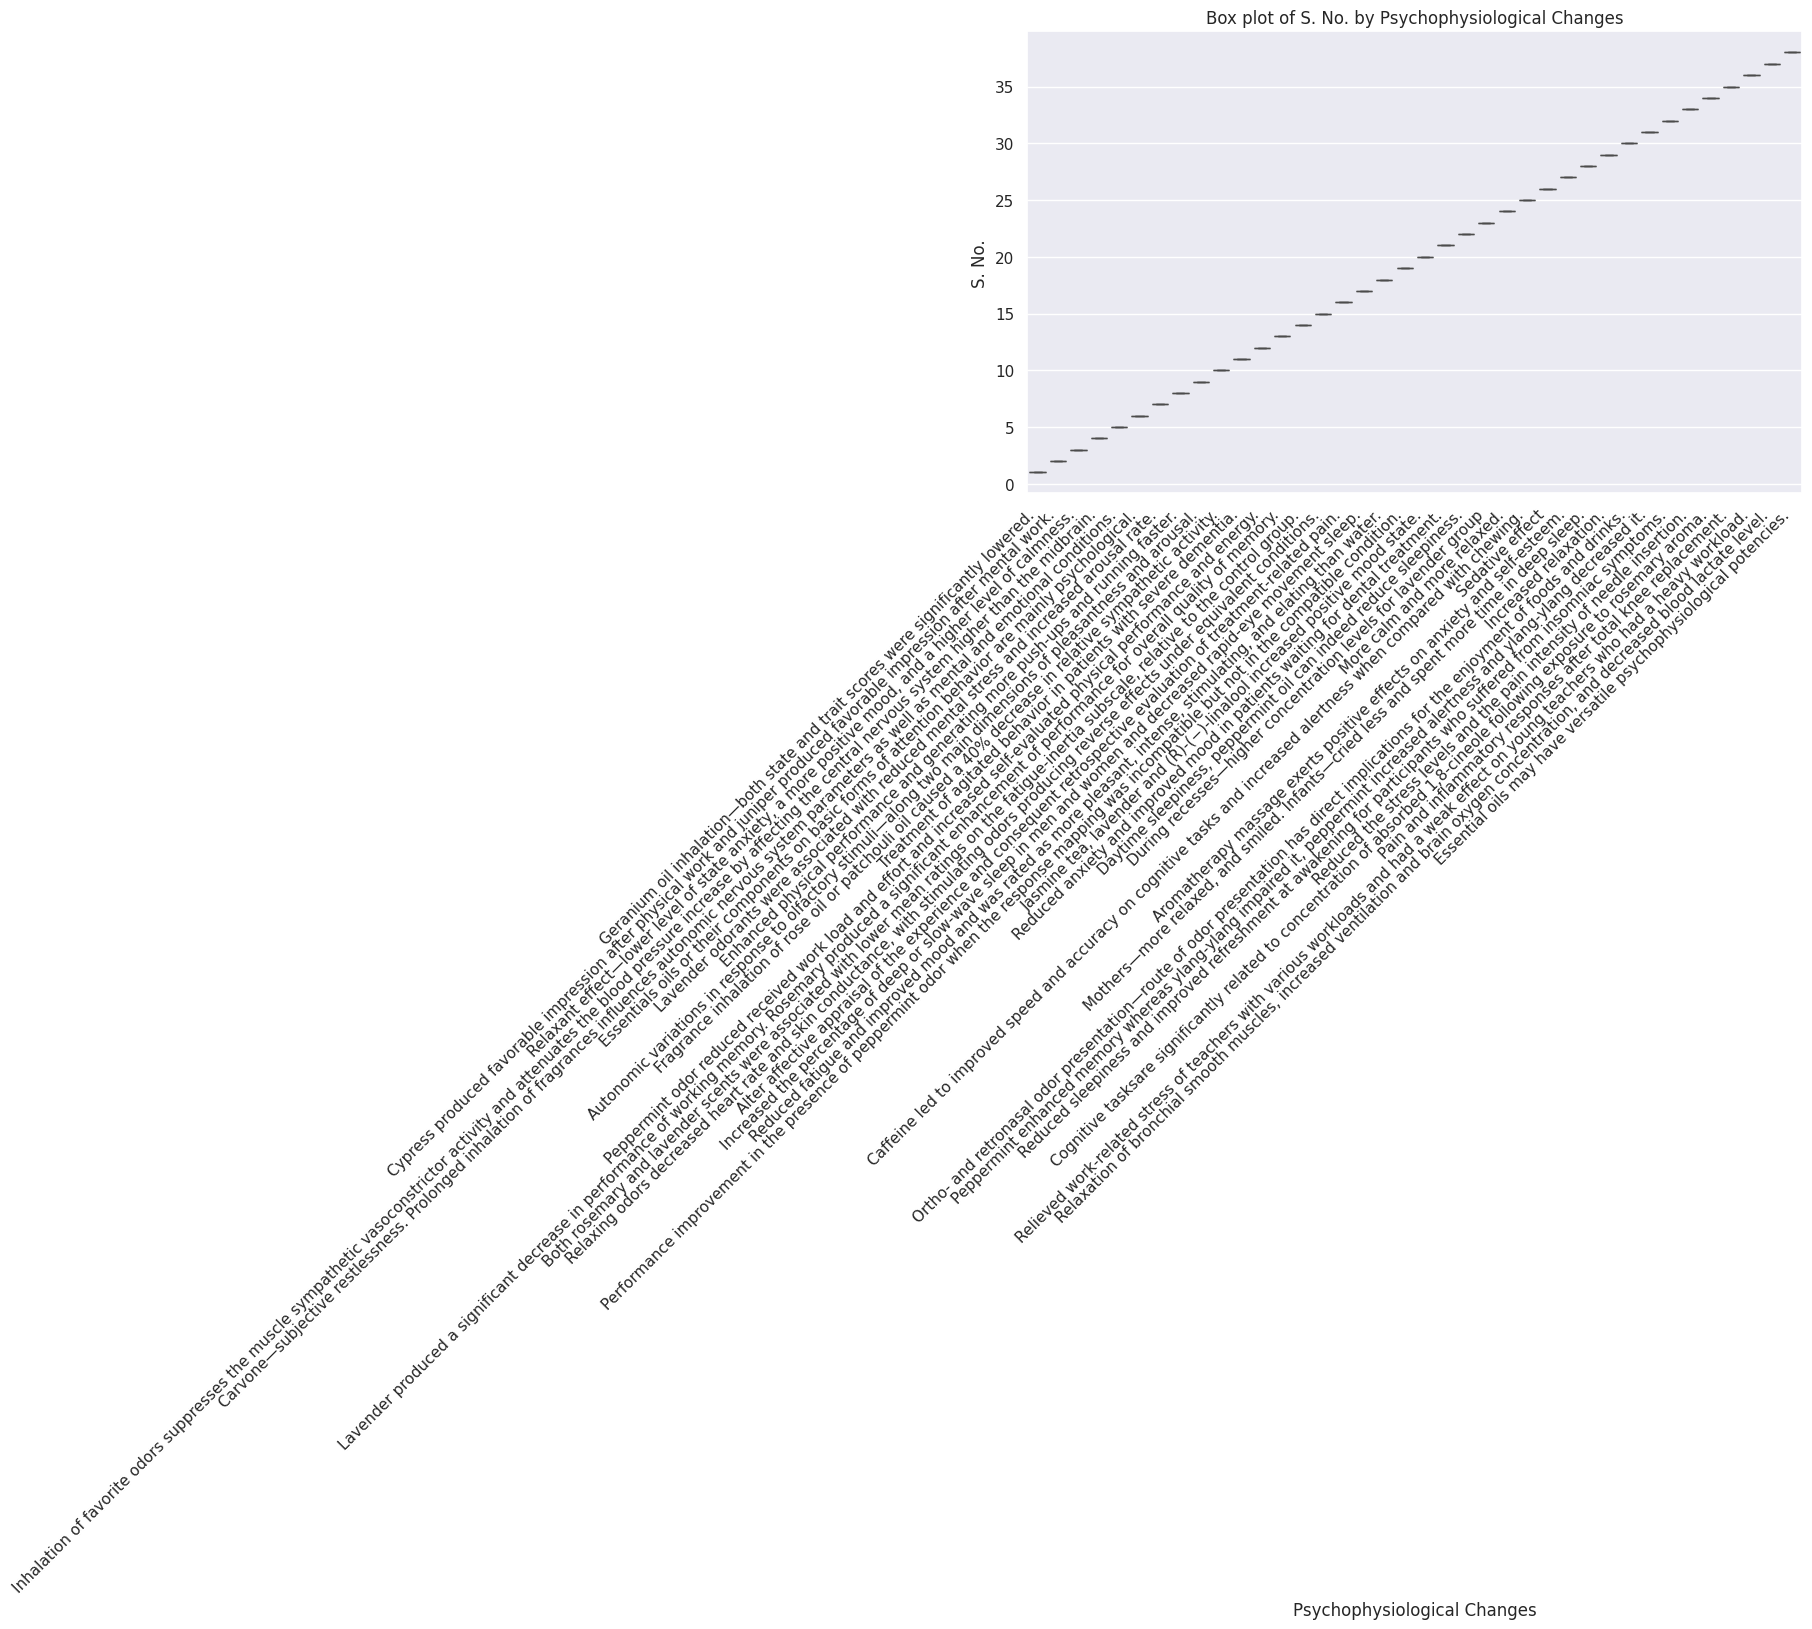

Skipping box plot for 'S. No.' by 'Plants Name': No non-null data points to plot.
Skipping box plot for 'S. No.' by 'Botanical Name': No non-null data points to plot.
Skipping box plot for 'S. No.' by 'Major Components': No non-null data points to plot.


In [17]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df_combined.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df_combined, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df_combined.select_dtypes(include='object').columns.tolist()
numerical_cols = df_combined.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        # Drop NaN values for the specific categorical and numerical columns being plotted
        plot_df = df_combined[[cat_col, num_col]].dropna()

        # Skip plotting if there's no data after dropping NaNs
        if plot_df.empty:
            print(f"Skipping box plot for '{num_col}' by '{cat_col}': No non-null data points to plot.")
            continue

        plt.figure(figsize=(10, 6))
        sns.boxplot(data=plot_df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

# Word Cloud

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


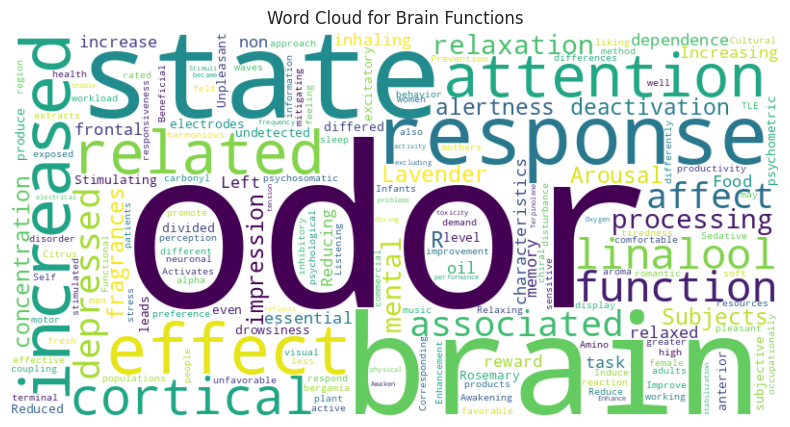

In [21]:
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk

# Download stopwords if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

# Combine all text from 'Brain Functions' column, handling NaNs
text = " ".join(df_combined['Brain Functions'].dropna().astype(str))

# Define stop words
stop_words = set(stopwords.words('english'))

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Brain Functions')
plt.show()

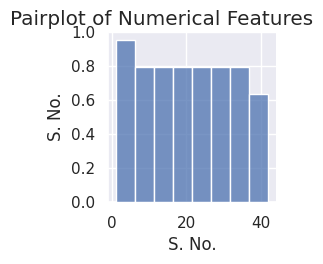

In [18]:
sns.pairplot(df_combined.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

### Grouped Bar Chart for Specific Categorical Relationships

For some relationships between categorical columns, especially when focusing on the distribution of one variable within specific categories of another, grouped or stacked bar charts can be very insightful. For example, let's look at the distribution of different 'EEG Wave Changes' for the most frequent 'Odorant Materials'.

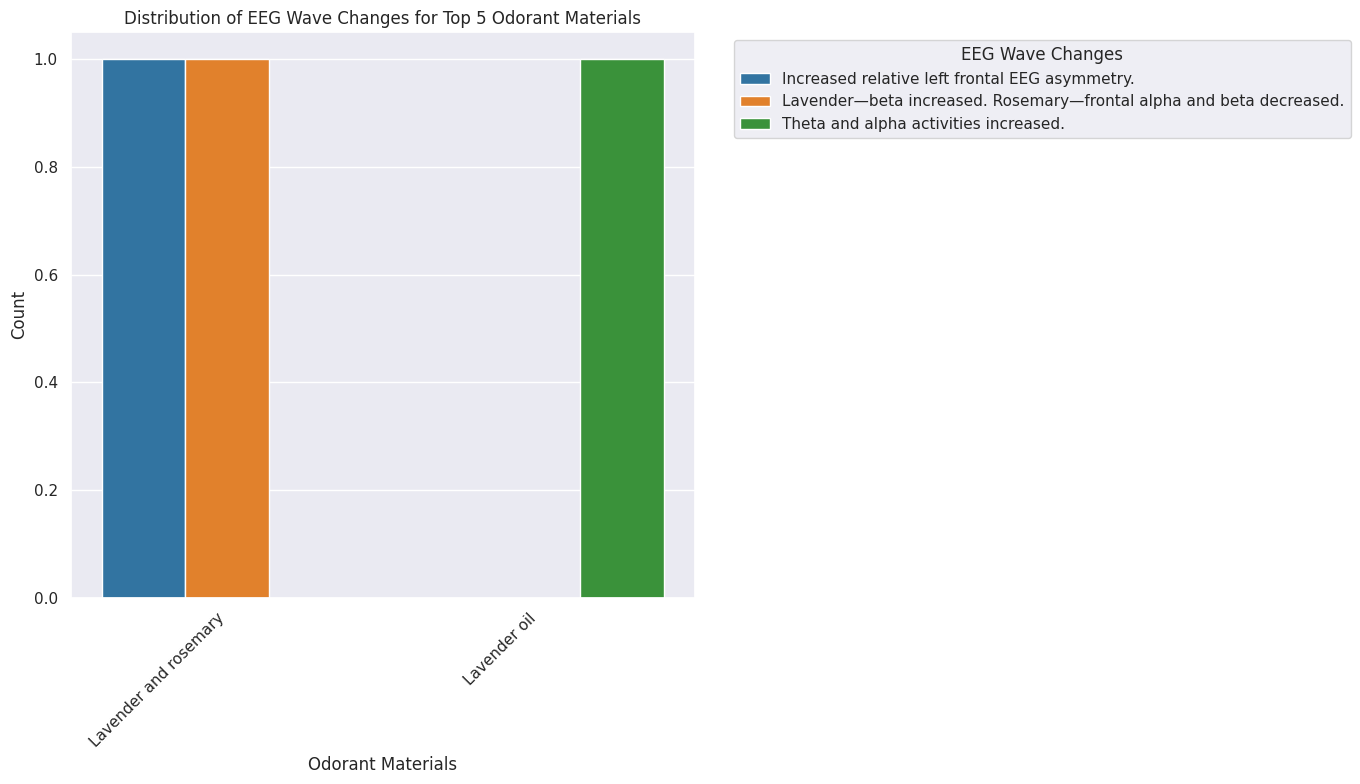

In [25]:
# Getting the top 5 most frequent Odorant Materials
top_5_odorants = df_combined['Odorant Materials'].value_counts().nlargest(5).index

# Filtering the DataFrame to include only these top odorants and non-null EEG Wave Changes
df_filtered_eeg = df_combined[
    df_combined['Odorant Materials'].isin(top_5_odorants) &
    df_combined['EEG Wave Changes'].notna()
]

# Counting the occurrences for plotting
plot_data = df_filtered_eeg.groupby(['Odorant Materials', 'EEG Wave Changes']).size().reset_index(name='Count')

# Plotting a grouped bar chart
plt.figure(figsize=(14, 8))
sns.barplot(
    data=plot_data,
    x='Odorant Materials',
    y='Count',
    hue='EEG Wave Changes',
    palette='tab10'
)
plt.title('Distribution of EEG Wave Changes for Top 5 Odorant Materials')
plt.xlabel('Odorant Materials')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='EEG Wave Changes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

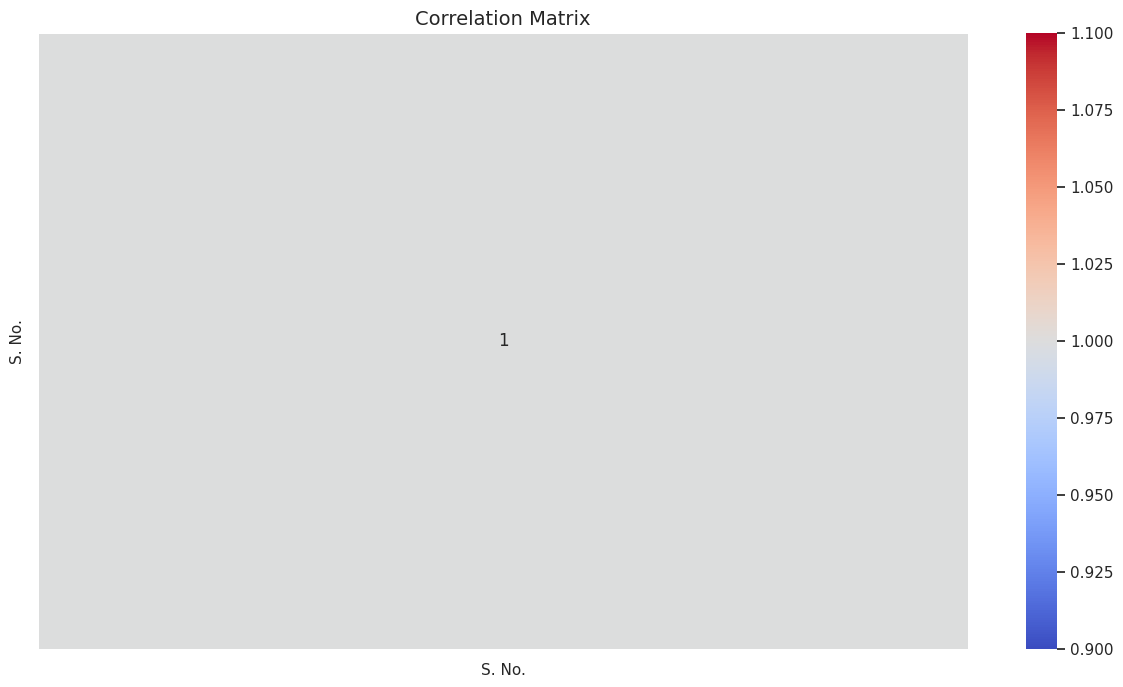

In [19]:
plt.figure(figsize=(15, 8))
sns.heatmap(df_combined.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

### Heatmap of Categorical Relationship: Odorant Materials vs. EEG Wave Changes

To visualize the relationship between two categorical variables, a heatmap of their contingency table (crosstab) is highly effective. Given the high number of unique 'Odorant Materials', we'll first select the top 10 most frequent odorants to make the visualization more interpretable. This will show us how often specific EEG wave changes are associated with particular odorant materials.

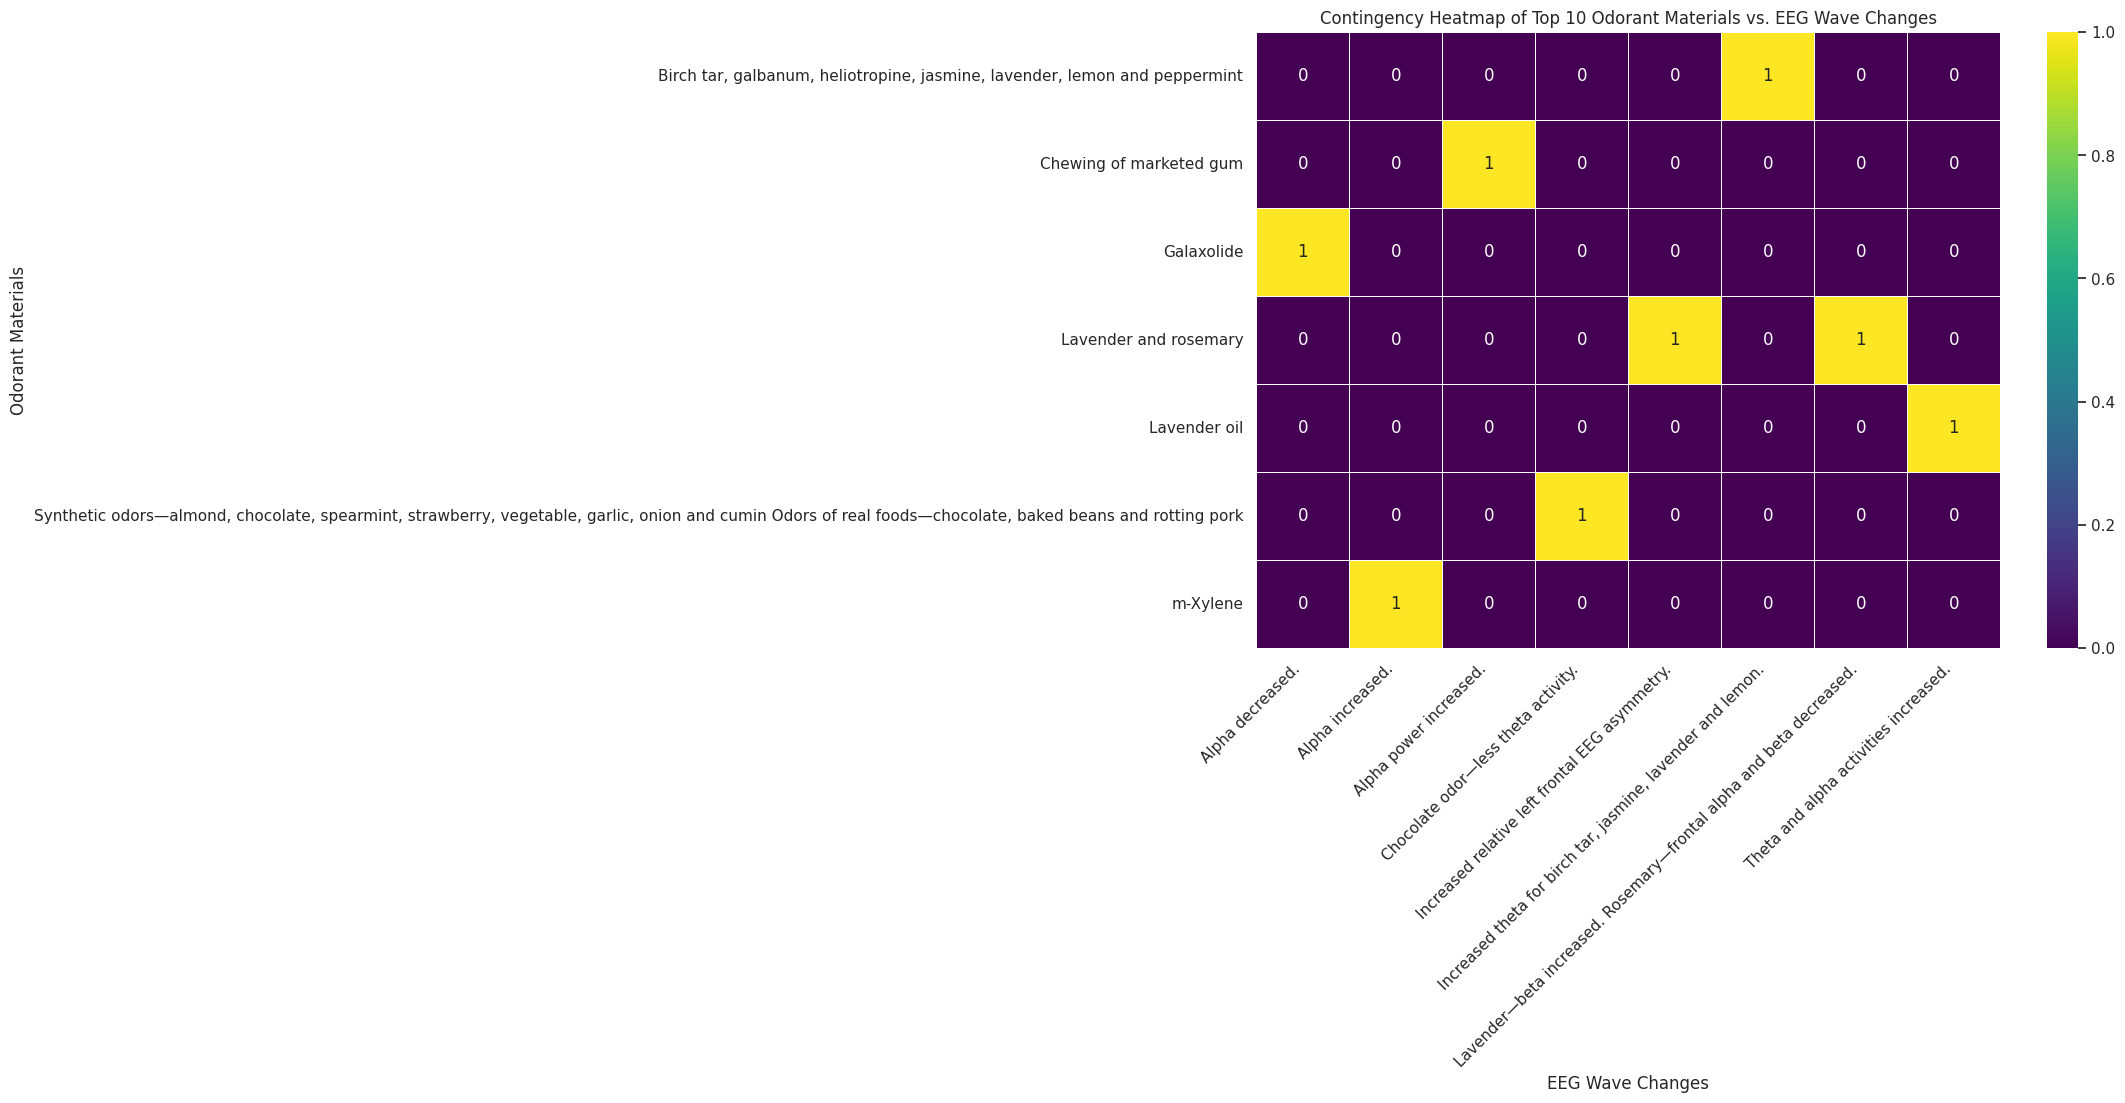

In [20]:
# Get the top 10 most frequent Odorant Materials
top_odorants = df_combined['Odorant Materials'].value_counts().nlargest(10).index

# Filter the DataFrame to include only these top odorants
df_filtered = df_combined[df_combined['Odorant Materials'].isin(top_odorants)]

# Create a contingency table (crosstab) for the filtered data
contingency_table = pd.crosstab(df_filtered['Odorant Materials'], df_filtered['EEG Wave Changes'])

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='viridis', linewidths=.5)
plt.title('Contingency Heatmap of Top 10 Odorant Materials vs. EEG Wave Changes')
plt.xlabel('EEG Wave Changes')
plt.ylabel('Odorant Materials')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Thank You